# CS 614 - Applications of Machine Learning 
## Programming Assignment 4 - Faster R-CNN
In this assignment we'll use a **pretrained** Faster R-CNN to detect objects in an image.  We will generally follow the following article/tutorial:
https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html

The following link can also be useful
https://docs.pytorch.org/vision/main/auto_examples/others/plot_visualization_utils.html#instance-seg-output

### ROCm kernel: "Couldn't load custom C++ ops" fix

Faster R-CNN needs torchvision's **custom C++ ops** (e.g. NMS). The **ROCm torchvision** wheel often does not load them, so this error can persist even after reinstall.

**Recommended:** Run this notebook with the **cs614** kernel (CPU or CUDA) so detection works.

1. If you don't have it: `make setup` then add the kernel to Jupyter if needed.
2. In the notebook: **Kernel → Change Kernel → Python (cs614)** (or whatever your main conda env is called).
3. Re-run all cells. You need matching torch + torchvision from the same env (e.g. both from pip/conda).

If you insist on ROCm, try reinstalling the ROCm torchvision wheel (use `--no-deps`):

```bash
conda activate /opt/rocm-pytorch
pip uninstall torchvision -y
pip install https://repo.radeon.com/rocm/manylinux/rocm-rel-5.7/torchvision-0.15.2+rocm5.7-cp311-cp311-linux_x86_64.whl --no-deps
```
Ensure **torch** in that env is **2.0.1+rocm5.7** (not 2.10+cu128). If the error still appears, use the cs614 kernel.

In [1]:
# Check versions (torch 2.0.1+rocm5.7 expects torchvision 0.15.2+rocm5.7)
import torch
import torchvision
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
# If you see the custom C++ ops error, run the reinstall command in the markdown above.

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


### Get Your data
Let's do things a little differently.  Obtain **two** images of your own liking, a use the loaded model to find objects in it.

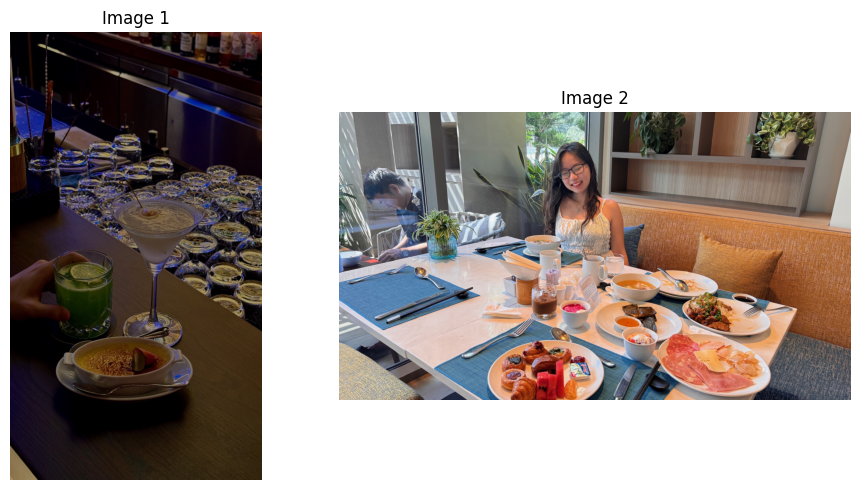

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torchvision
import torch

# Read in your images and visualize them
# Replace the filenames below with two images of your choice
img_paths = [
    "images/1.jpg", 
    "images/2.jpg",
]

# Load images with PIL
pil_images = [Image.open(p).convert("RGB") for p in img_paths]

# Visualize the two input images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, img, title in zip(axes, pil_images, ["Image 1", "Image 2"]):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Assuming you read in your images with pillow, this will convert to a set of pytorch tensors
imglist = [torchvision.transforms.functional.pil_to_tensor(img) for img in pil_images]

### Import Model
Next, let's import a pretrained model.   We'll use a Faster R-CNN model trained on the ResNet-50 FPN dataset

In [3]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)

#Print out the model and meta data about the weights to see what's in it!
print(model)
print(weights.meta)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

### Get Transform, Classes, and Create Colors
From the model we can get the transform used to pre-process images and the list of classes, the latter of which we can use to create a set of colors to annotate our detections.

In [4]:
transforms = weights.transforms()
classes = weights.meta["categories"]

# create a set of random (RGB) colors, one per class
# this must be a set of tuples. Each tuple has three elements (R,G,B) in range [0,255]
np.random.seed(0)
num_classes = len(classes)
colors = np.random.randint(0, 256, size=(num_classes, 3), dtype=np.uint8)


### Use the Model for Detection and Classification!


In [5]:
# For inference
model.eval()
# First pre-process the images using the model's transform
images = [transforms(d) for d in imglist]
predictions = model(images)  # Returns predictions for all images

# For each image determine all detections above some threshold. Play with the threshold!
score_threshold = 0.8
locs_list = []  # list of indices of kept detections for each image

for img_idx, pred in enumerate(predictions):
    locs = []
    scores = pred["scores"]
    for i in range(scores.shape[0]):
        if scores[i] > score_threshold:
            locs.append(i)
    locs_list.append(locs)

    # Display the class, bounding box, and probability of each of the detections found above
    print(f"\nDetections for Image {img_idx + 1} with score_threshold={score_threshold}:")
    if len(locs) == 0:
        print("  No detections above threshold.")
    else:
        # Print a header row for alignment
        print(f"  {'Idx':>3} | {'Class':15s} | {'Score':>6} | Box [x1, y1, x2, y2]")
        print("  " + "-" * 72)
        for i in locs:
            label_idx = pred["labels"][i].item()
            class_name = classes[label_idx]
            box = pred["boxes"][i].tolist()
            score = pred["scores"][i].item()
            print(f"  {i:3d} | {class_name:15s} | {score:6.3f} | {box}")


Detections for Image 1 with score_threshold=0.8:
  Idx | Class           |  Score | Box [x1, y1, x2, y2]
  ------------------------------------------------------------------------
    0 | wine glass      |  0.991 | [651.7799072265625, 978.6282348632812, 1148.2266845703125, 1899.0526123046875]
    1 | cup             |  0.990 | [267.7205810546875, 1321.1671142578125, 622.4137573242188, 1877.9769287109375]
    2 | bowl            |  0.985 | [342.9910583496094, 1845.181396484375, 1064.69775390625, 2175.854248046875]
    3 | dining table    |  0.971 | [9.853137016296387, 1328.8575439453125, 1533.1688232421875, 2671.254638671875]
    4 | bottle          |  0.958 | [1269.501220703125, 1.5683451890945435, 1358.8834228515625, 214.2415771484375]
    5 | bottle          |  0.942 | [1034.4224853515625, 0.22036847472190857, 1124.478759765625, 151.22425842285156]
    6 | bottle          |  0.920 | [1187.3336181640625, 1.237202525138855, 1283.189208984375, 194.92343139648438]
    7 | spoon         

### Annotate Detections
Now lets add color-coded bounding boxes to the original images to denote detection and classification

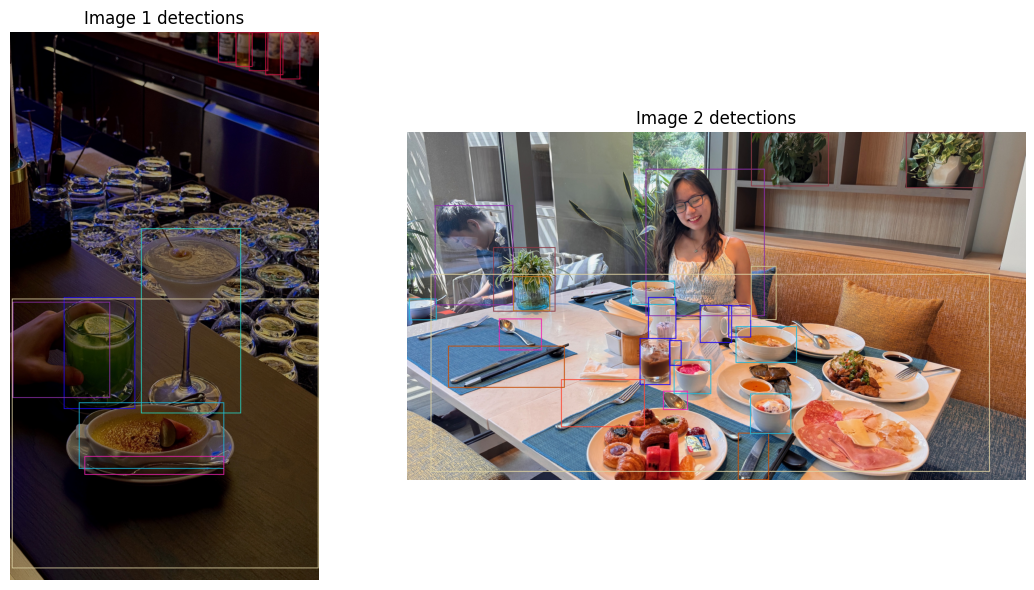

In [6]:
from torchvision.utils import draw_bounding_boxes

# Visualize detections for both images with color-coded bounding boxes
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for img_idx, (ax, pred, locs) in enumerate(zip(axes, predictions, locs_list)):
    if len(locs) == 0:
        # If no detections above threshold, just show the original image
        ax.imshow(np.transpose(np.asarray(imglist[img_idx]), (1, 2, 0)))
        ax.set_title(f"Image {img_idx + 1} (no detections)")
        ax.axis("off")
        continue

    # Get the colors for the detected items
    clrs = colors[pred["labels"][locs].tolist()]
    # convert this to tuples to pass to draw_bounding_boxes
    tcolors = [tuple(row) for row in clrs]

    img_with_boxes = draw_bounding_boxes(imglist[img_idx], pred["boxes"][locs], colors=tcolors, width=4)
    ax.imshow(np.transpose(np.asarray(img_with_boxes), (1, 2, 0)))
    ax.set_title(f"Image {img_idx + 1} detections")
    ax.axis("off")

plt.tight_layout()
plt.show()